# 先行研究3：潜在変数の相転移

In [1]:
import sys
from pathlib import Path

# projectルートを追加
sys.path.append(str(Path().resolve().parent))
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("numpy:",np.__version__)
print("pandas:",pd.__version__)
print("matplotlib:",matplotlib.__version__)

numpy: 2.4.2
pandas: 3.0.1
matplotlib: 3.10.8


## 標本自己相関
### 指数減衰
$$
k(x, x') = \sigma^2 \exp\left(-\frac{|x - x'|}{\ell}\right)
$$

自己相関
$$
\rho(h) \sim \theta^h
$$

### べき乗減衰
$$
k(x, x') = \frac{\sigma^2}{(1 + |x - x'|)^{\gamma}}
$$
自己相関
$$
\rho(h) \sim h^{-\gamma}
$$

In [2]:
def _pairwise_dist(X1, X2):
    return np.abs(X1 - X2.T)

def _pairwise_sqdist(X1, X2):
    return (X1 - X2.T) ** 2

def kernel_exponential(X1, X2, sigma=1.0, ell=1.0):
    dist = _pairwise_dist(X1, X2)
    return sigma**2 * np.exp(-dist / ell)
    
def kernel_power_law_like(X1, X2, sigma=1.0, gamma=0.7):
    dist = _pairwise_dist(X1, X2)
    return sigma**2 / ((1 + dist) ** gamma)

In [3]:
def sample_gp(K, mean=None ,n_samples=5, jitter=1e-6):
    n = K.shape[0] # size kernel
    K_stable = K + jitter * np.eye(n) # positive definite
    if mean is None:
        mean = np.zeros(n)
    return np.random.multivariate_normal(mean, K_stable, size=n_samples)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def sample_acf(series, max_lag=30):
    x = np.asarray(series, dtype=float)
    x = x - np.mean(x)
    n = len(x)

    denom = np.dot(x, x)
    if denom <= 0:
        return np.zeros(max_lag + 1)

    acf_vals = [1.0]
    for lag in range(1, max_lag + 1):
        num = np.dot(x[:-lag], x[lag:])
        acf_vals.append(num / denom)

    return np.array(acf_vals)

def plot_kernel_samples_and_acf(x, K, samples, title, max_lag=30):
    max_lag = int(max_lag)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # 1. covariance matrix
    im = axes[0].imshow(K, origin="upper", aspect="auto")
    axes[0].set_title(f"{title} covariance")
    plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

    # 2. prior samples
    for i in range(samples.shape[0]):
        if i >= 3:
            break
        axes[1].plot(x.ravel(), samples[i], lw=1.5)
    axes[1].set_title(f"{title} prior samples")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("f(x)")
    axes[1].grid(True, alpha=0.3)

    # 3. sample ACF of the last sample
    acf_list = []
    for s in samples:
        acf_s = sample_acf(s, max_lag=max_lag)
        acf_list.append(acf_s)

    acf_array = np.array(acf_list)

    acf_mean = acf_array.mean(axis=0)
    acf_std = acf_array.std(axis=0)

    lags = np.arange(max_lag + 1)

    axes[2].plot(lags, acf_mean, label="mean ACF")
    axes[2].fill_between(
        lags,
        acf_mean - acf_std,
        acf_mean + acf_std,
        alpha=0.3,
        label="±1 std"
    )

    axes[2].axhline(0.0, color="black", lw=1)
    axes[2].set_title(f"{title} sample ACF (mean ± std)")
    axes[2].set_xlabel("lag")
    axes[2].set_ylabel("ACF")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

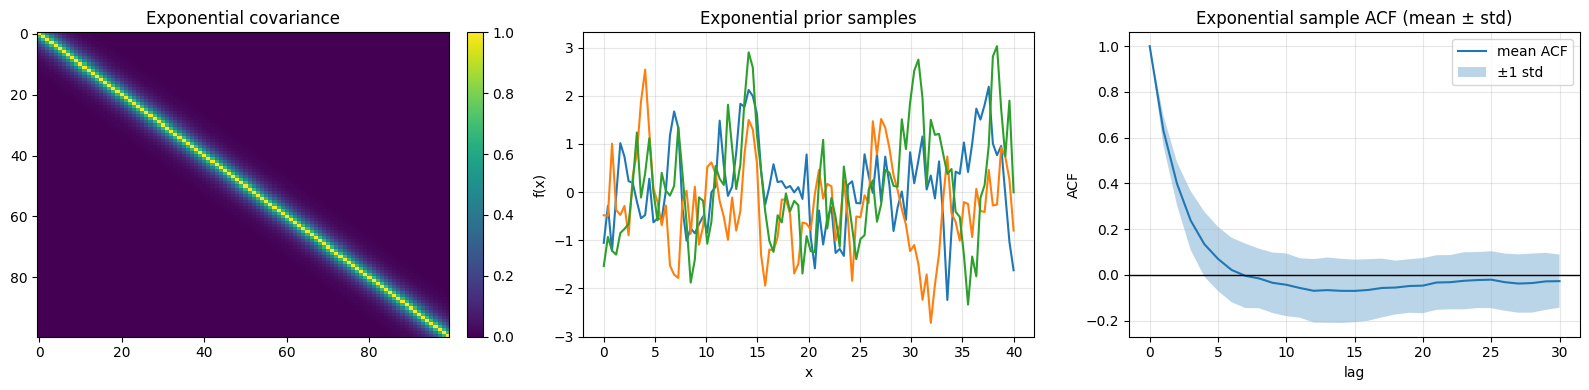

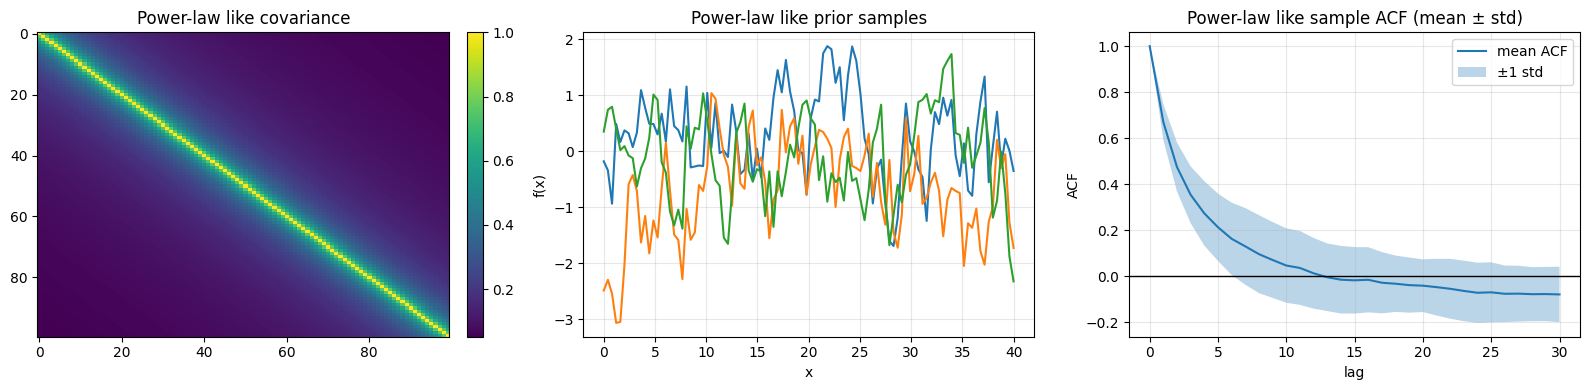

In [5]:
# input
np.random.seed(42)
x = np.linspace(0, 40, 100)[:, None]   # Delta x = 0.4

kernels = {
    "Exponential": kernel_exponential(x, x, sigma=1.0, ell=1.0),
    "Power-law like": kernel_power_law_like(x, x, sigma=1.0, gamma=0.8),
}

for name, K in kernels.items():
    samples = sample_gp(K, n_samples=100, jitter=1e-6)
    plot_kernel_samples_and_acf(x, K, samples, name, max_lag=30)

## 強度累積和の分散スケーリング

### 強度の総和の分散
$$
\text{Var}\left(\lambda_T = \sum^T_{t=1} \lambda_t \right) \simeq \bar{V}T + 2\bar{V}\sum^{T-1}_{i=1} d_i(T-i)
$$
ただし$\bar{V}=\text{Var}(\lambda_t)$

#### 指数減衰
$$
\text{Var}\left(\lambda_T = \sum^T_{t=1} \lambda_t \right) \simeq \bar{V}T + 2\bar{V}\sum^{T-1}_{i=1} \theta^i(T-i)
$$

$T \to \infty$の漸近領域の時

$$
\text{Var}(\lambda_t) \propto T \ ,\ \log{\text{Var}(\lambda_t) \propto \log{T}}
$$

#### べき乗減衰
$$
\text{Var}\left(\lambda_T = \sum^T_{t=1} \lambda_t \right) \simeq \bar{V}T + 2\bar{V}\sum^{T-1}_{i=1} \frac{T-i}{(1+i)^{\gamma}}
$$

$T \to \infty$の漸近領域の時

$(\gamma > 1)$
$$
\text{Var}(\lambda_t) \propto T \ ,\ \log{\text{Var}(\lambda_t) \propto \log{T}}
$$

$(\gamma = 1)$
$$
\text{Var}(\lambda_t) \propto T\log{T}
$$

$(\gamma < 1)$
$$
\text{Var}(\lambda_t) \propto T^{2-\gamma}\ ,\ \log{\text{Var}(\lambda_t) \propto (2-\gamma)\log{T}}
$$

### Fig2の再現
$$
\frac{Z_T}{T} = \frac{1}{T}\frac{\text{Var}(\lambda_T) }{ \text{Var}(\lambda(y))}
$$

※論文では$Z_T$となっているがおそらく誤植

- 短期記憶なら定数に落ち着く
- 長期記憶なら発散する

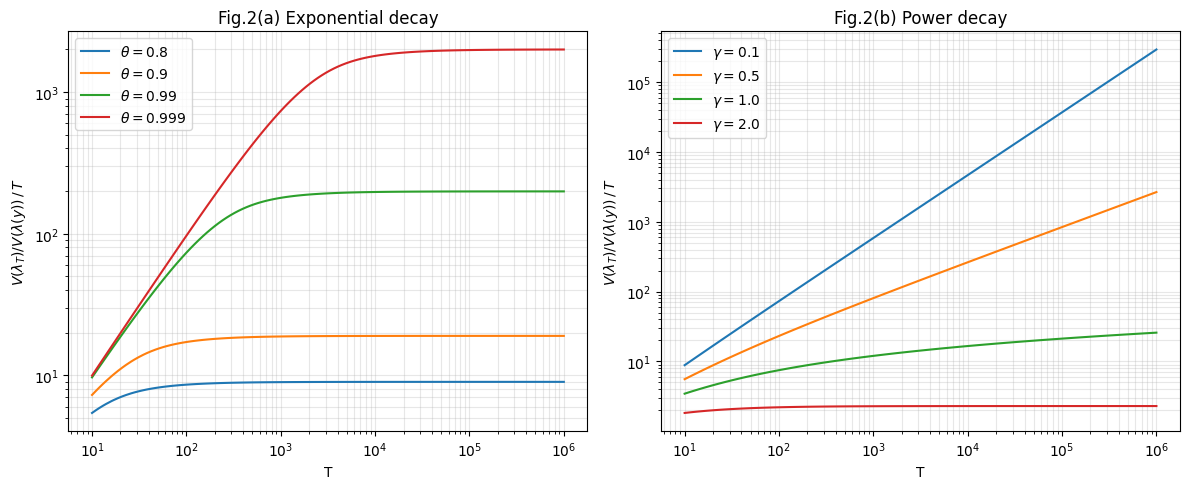

In [6]:
# -----------------------------
# Z_T = V(lambda_T) / V(lambda(y))
# 論文の式では Vbar が共通因子なので 1 としてよい
# -----------------------------
def z_exp(T, theta):
    i = np.arange(1, T)
    return T + 2.0 * np.sum((theta ** i) * (T - i))

def z_pow(T, gamma):
    i = np.arange(1, T)
    return T + 2.0 * np.sum(((i + 1.0) ** (-gamma)) * (T - i))

# -----------------------------
# Fig.2 再現
# -----------------------------
T_grid = np.unique(np.logspace(1, 6, 120).astype(int))  # 10 ~ 10000
theta_list = [0.8, 0.9, 0.99, 0.999]
gamma_list = [0.1, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) exponential
for theta in theta_list:
    zvals = np.array([z_exp(T, theta) for T in T_grid], dtype=float)
    axes[0].loglog(T_grid, zvals / T_grid, label=fr"$\theta={theta}$")
axes[0].set_title("Fig.2(a) Exponential decay")
axes[0].set_xlabel("T")
axes[0].set_ylabel(r"$V(\lambda_T)/V(\lambda(y)) \,/\, T$")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

# (b) power
for gamma in gamma_list:
    zvals = np.array([z_pow(T, gamma) for T in T_grid], dtype=float)
    axes[1].loglog(T_grid, zvals / T_grid, label=fr"$\gamma={gamma}$")
axes[1].set_title("Fig.2(b) Power decay")
axes[1].set_xlabel("T")
axes[1].set_ylabel(r"$V(\lambda_T)/V(\lambda(y)) \,/\, T$")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 有限サイズ指標
### Fig3の再現
**指数 vs べきは有限データでは区別が難しい**

そこで有限サイズ指標$\delta$を導入する。
$\text{Var}(\lambda_T) \propto T^{\beta}$として 

$$
\frac{\text{Var}({\lambda_T})}{\text{Var}(\lambda_{2T})} = 2^{-\beta}
$$

この対数-対数プロットが$-\beta$となり、$\delta < -1$で$\text{long memory}$と主張しやすい

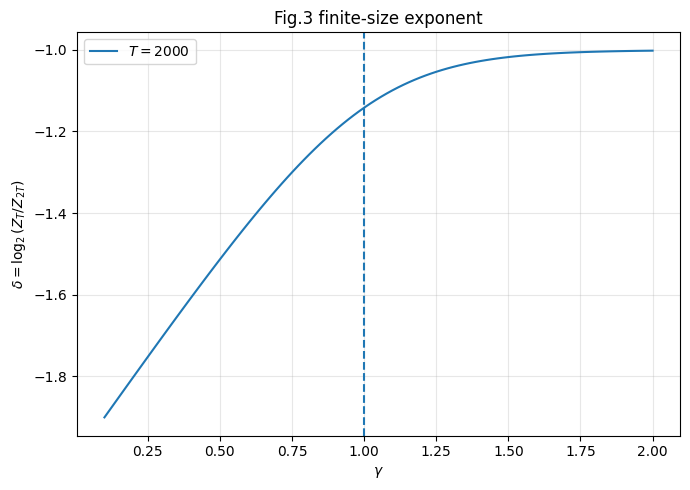

In [7]:
# -----------------------------
# Fig.3 再現
# delta = log2( Z_T / Z_2T )
# alpha は理論式上この比で消えるので、
# 論文の凡例 alpha=1.0, 0.5 は見た目上は一致しやすい
# -----------------------------
gamma_grid = np.linspace(0.1, 2.0, 100)
T0 = 2000

delta_vals = []
for gamma in gamma_grid:
    zT = z_pow(T0, gamma)
    z2T = z_pow(2 * T0, gamma)
    delta_vals.append(np.log2(zT / z2T))
delta_vals = np.array(delta_vals)

plt.figure(figsize=(7, 5))
plt.plot(gamma_grid, delta_vals, label=fr"$T={T0}$")
plt.axvline(1.0, linestyle="--")
plt.title("Fig.3 finite-size exponent")
plt.xlabel(r"$\gamma$")
plt.ylabel(r"$\delta = \log_2(Z_T/Z_{2T})$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

最後に複数の世界戦でデータをとり、$\lambda_T$の分散を可視化してみる

In [10]:
# input
np.random.seed(42)
x = np.linspace(0, 1000, 1000)[:, None]   # Delta x = 0.4

In [11]:
def to_intensity(samples, lambda0=1.0, alpha=1.0):
    """
    samples: shape (n_samples, T)
    return : shape (n_samples, T)
    """
    return lambda0 * np.exp(alpha * samples)

def cumulative_sum_variance(lam_samples):
    """
    lam_samples: shape (n_samples, T)
    return
        T_vals: shape (T,)
        var_vals: shape (T,)
    """
    cumsum = np.cumsum(lam_samples, axis=1)   # shape (n_samples, T)
    var_vals = np.var(cumsum, axis=0, ddof=1) # 各時点Tでサンプル間分散
    T_vals = np.arange(1, lam_samples.shape[1] + 1)
    return T_vals, var_vals
    
def finite_size_indicator(var_vals):
    """
    var_vals: shape (T,)
    return
        T_base: T
        delta : log(Var(S_T) / Var(S_{2T}))
    """
    T_max = len(var_vals)
    T_base = np.arange(1, T_max // 2 + 1)
    delta = np.log(var_vals[T_base - 1] / var_vals[2 * T_base - 1])
    return T_base, delta

In [12]:
ex_K = kernel_exponential(x, x, sigma=1.0, ell=1.0)
ex_samples = sample_gp(ex_K, n_samples=100, jitter=1e-6)

pow_K = kernel_power_law_like(x, x, sigma=1.0, gamma=0.7)
pow_samples = sample_gp(pow_K, n_samples=100, jitter=1e-6)

lambda0 = 1.0
alpha = 1.0

ex_lambda = to_intensity(ex_samples, lambda0=lambda0, alpha=alpha)
pow_lambda = to_intensity(pow_samples, lambda0=lambda0, alpha=alpha)

T_ex, var_ex = cumulative_sum_variance(ex_lambda)
T_pow, var_pow = cumulative_sum_variance(pow_lambda)

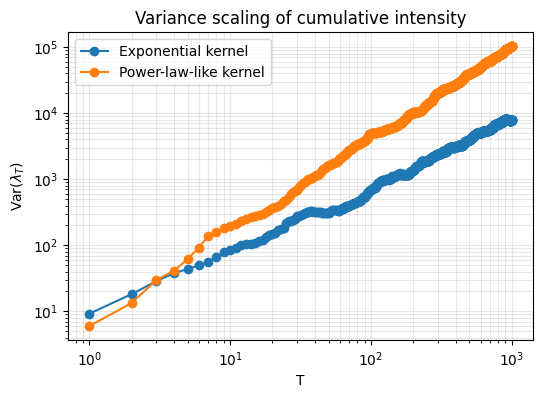

In [13]:
plt.figure(figsize=(6, 4))
plt.loglog(T_ex, var_ex, marker="o", label="Exponential kernel")
plt.loglog(T_pow, var_pow, marker="o", label="Power-law-like kernel")
plt.xlabel("T")
plt.ylabel("Var($\lambda_T$)")
plt.title("Variance scaling of cumulative intensity")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

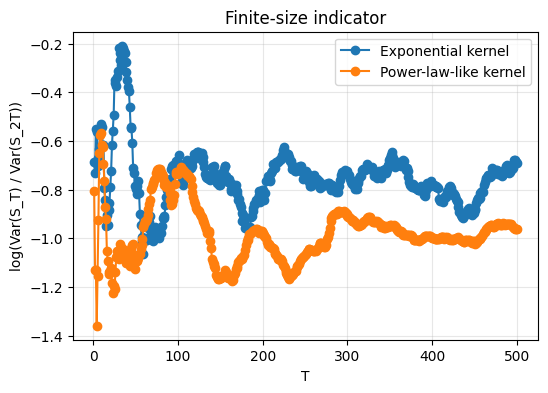

In [14]:
T_base_ex, delta_ex = finite_size_indicator(var_ex)
T_base_pow, delta_pow = finite_size_indicator(var_pow)

plt.figure(figsize=(6, 4))
plt.plot(T_base_ex, delta_ex, marker="o", label="Exponential kernel")
plt.plot(T_base_pow, delta_pow, marker="o", label="Power-law-like kernel")
plt.xlabel("T")
plt.ylabel("log(Var(S_T) / Var(S_2T))")
plt.title("Finite-size indicator")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()